# Desafio Técnico - Squad WhatsApp

### Objetivo de negócio
Este notebook constrói uma inteligência de priorização para selecionar os telefones com maior probabilidade de sucesso no disparo de WhatsApp.

### Entregáveis cobertos
- Qualidade comparativa por sistema de origem (`id_sistema_mask`).
- Análise de decaimento por tempo desde atualização do telefone.
- Ranking matemático de confiabilidade por sistema.
- Algoritmo para escolher os 2 melhores telefones por CPF.
- Desenho de experimento A/B para validação em produção.

### Arquivos usados:
- `whatsapp_base_disparo_mascarado`
- `whatsapp_dim_telefone_mascarado`

## Parte 1 - Analise exploratória

1. Relacionar sistema de origem (`id_sistema_mask`) com status de disparos (`status_disparo`), com foco em taxa de entrega.

2. Avaliar o efeito da atualidade (`registro_data_atualizacao`) na taxa de sucesso.



### Importação de arquivos

In [1]:
# Bibliotecas e configurações iniciais

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
# Importação do arquivo Base Disparo

base_disparo = pd.read_parquet("whatsapp_base_disparo_mascarado")

print(base_disparo.shape)
base_disparo.head(3)

(392921, 16)


,id_conta,id_hsm,id_disparo,id_sessao,cpf,id_target,contato_telefone,categoria_hsm,ambiente,criacao_envio_datahora,envio_datahora,falha_datahora,descricao_falha,indicador_falha,id_status_disparo,status_disparo
0,-9142586270102516767,-7590735594542127444,-2317524427909960986,NaN,-5.220753e+18,9206664160911476254,2824089259510570290,Utilidade,prod,2025-10-07 13:14:53.037,2025-10-07 13:15:17.204,NaT,None,False,1,processing
1,-9142586270102516767,-3785213779161126614,-6855906542267037066,NaN,-7.869927e+18,6874603298726099113,-4599056651977889342,Utilidade,prod,2025-10-25 10:56:24.194,2025-10-25 10:56:45.028,NaT,None,False,1,processing
2,-9142586270102516767,-9203817354237048492,-4043820570593848035,NaN,5.192496e+18,-1874111216941729257,-1731551129526467355,Utilidade,prod,2025-10-29 11:04:14.987,2025-10-29 11:04:45.562,NaT,None,False,1,processing


In [3]:
# Importação do arquivo DIM Telefone

dim_telefone = pd.read_parquet("whatsapp_dim_telefone_mascarado")

print(dim_telefone.shape)
dim_telefone.head(3)

(283289, 11)


,telefone_ddi,telefone_ddd,telefone_numero,telefone_tipo,telefone_nacionalidade,telefone_qualidade,telefone_aparicoes,telefone_aparicoes_quantidade,telefone_proprietarios_quantidade,telefone_sistemas_quantidade,validacao_telefone
0,55,-1181433720517268842,-6862804366069381626,CELULAR,Brasil,VALIDO,"[{'id_sistema': '1257277410380486863', 'cpf': ...",1,1,1,"{'ddd_valido_br': True, 'formato_valido': True..."
1,55,-1181433720517268842,3856002700049294556,CELULAR,Brasil,VALIDO,"[{'id_sistema': '3094574413675758272', 'cpf': ...",1,1,1,"{'ddd_valido_br': True, 'formato_valido': True..."
2,55,-1181433720517268842,8067166217402075300,CELULAR,Brasil,VALIDO,"[{'id_sistema': '3094574413675758272', 'cpf': ...",1,1,1,"{'ddd_valido_br': True, 'formato_valido': True..."


### Checagem de qualidade dos dados

In [4]:
# Tipos de colunas

print('Tipos de coluna em base_disparo:')
display(base_disparo.dtypes)

print('Tipos de coluna em dim_telefone:')
display(dim_telefone.dtypes)

Tipos de coluna em base_disparo:


id_conta                           int64
id_hsm                             int64
id_disparo                         int64
id_sessao                        float64
cpf                              float64
id_target                          int64
contato_telefone                   int64
categoria_hsm                     object
ambiente                          object
criacao_envio_datahora    datetime64[us]
envio_datahora            datetime64[us]
falha_datahora            datetime64[us]
descricao_falha                   object
indicador_falha                     bool
id_status_disparo                  int64
status_disparo                    object
dtype: object

Tipos de coluna em dim_telefone:


telefone_ddi                         object
telefone_ddd                          int64
telefone_numero                       int64
telefone_tipo                        object
telefone_nacionalidade               object
telefone_qualidade                   object
telefone_aparicoes                   object
telefone_aparicoes_quantidade         int64
telefone_proprietarios_quantidade     int64
telefone_sistemas_quantidade          int64
validacao_telefone                   object
dtype: object

In [5]:
# Checagem de valores nulos

print('Nulos em base_disparo:')
display(base_disparo.isna().sum())

print('Nulos em dim_telefone:')
display(dim_telefone.isna().sum())

Nulos em base_disparo:


id_conta                       0
id_hsm                         0
id_disparo                     0
id_sessao                 156017
cpf                        31176
id_target                      0
contato_telefone               0
categoria_hsm                  0
ambiente                       0
criacao_envio_datahora         0
envio_datahora                 0
falha_datahora            365660
descricao_falha           365660
indicador_falha                0
id_status_disparo              0
status_disparo                 0
dtype: int64

Nulos em dim_telefone:


telefone_ddi                         0
telefone_ddd                         0
telefone_numero                      0
telefone_tipo                        0
telefone_nacionalidade               0
telefone_qualidade                   0
telefone_aparicoes                   0
telefone_aparicoes_quantidade        0
telefone_proprietarios_quantidade    0
telefone_sistemas_quantidade         0
validacao_telefone                   0
dtype: int64

In [6]:

# Status de disparo: importante para criar as taxas (entrega, sucesso, falha etc)

status_dist = (
    base_disparo['status_disparo']
    .value_counts(dropna=False)
    .rename_axis('status_disparo')
    .reset_index(name='qtde')
)
status_dist['pct'] = status_dist['qtde'] / status_dist['qtde'].sum()

display(status_dist)

print(f"Período dos disparos: {base_disparo['criacao_envio_datahora'].min()} até {base_disparo['criacao_envio_datahora'].max()}")


,status_disparo,qtde,pct
0,read,271566,0.691147
1,delivered,85405,0.217359
2,failed,27257,0.069370
3,sent,5533,0.014082
4,processing,3160,0.008042


Período dos disparos: 2025-09-03 09:42:39.787000 até 2026-04-18 14:28:07.439000


In [7]:
# Checagem de aparições
# Um telefone pode ter varias aparições, com sistema e data de atualização distintos

display(dim_telefone[dim_telefone['telefone_aparicoes_quantidade']>1][['telefone_numero','telefone_aparicoes', 'telefone_aparicoes_quantidade', 'telefone_qualidade']].head())

dim_telefone['telefone_aparicoes'][48708]

,telefone_numero,telefone_aparicoes,telefone_aparicoes_quantidade,telefone_qualidade
48708,8231373509248484653,"[{'id_sistema': '3094574413675758272', 'cpf': ...",2,VALIDO
48709,5580942104294601923,"[{'id_sistema': '3094574413675758272', 'cpf': ...",2,VALIDO
48710,-2610650737609854372,"[{'id_sistema': '1257277410380486863', 'cpf': ...",2,VALIDO
48711,-5777314259791929668,"[{'id_sistema': '3094574413675758272', 'cpf': ...",2,VALIDO
48712,-5232933994723894984,"[{'id_sistema': '1257277410380486863', 'cpf': ...",2,VALIDO


array([{'id_sistema': '3094574413675758272', 'cpf': 2851248869450150226, 'proprietario_tipo': 'CPF', 'registro_data_atualizacao': datetime.date(2025, 3, 22)},
       {'id_sistema': '4458959843028638627', 'cpf': 2851248869450150226, 'proprietario_tipo': 'CPF', 'registro_data_atualizacao': datetime.date(2025, 3, 22)}],
      dtype=object)

### Decisões de modelagem para análise

- Não há valores nulos nas chaves principais; portanto, a taxa de entrega por sistema não será distorcida por perda de informação e a análise de atualidade é viável.

- Podemos pensar em diferenças entre `taxa de entrega` (delivered) vs. `taxa de sucesso` (delivered ou read). Considerar sucesso de entrega como `status_disparo` em `['delivered', 'read']`.
- Explodir `telefone_aparicoes` para recuperar, por telefone, os sistemas de origem e as datas de atualização.
- Consolidar origem por `telefone_numero` e `id_sistema_mask`, mantendo a atualização mais recente disponível por sistema.
- Cruzar com a base de disparo via número do telefone (`contato_telefone`).


> **Observação executiva:** este passo é o núcleo para reduzir viés de seleção, pois separa volume de tentativas de taxa efetiva de sucesso.

### Tratamento dos dados

In [8]:
# Explode em telefone_aparicoes para pegar sistema e data de atualização

aparicoes = dim_telefone[
    ['telefone_numero', 'telefone_ddd', 'telefone_qualidade', 'telefone_aparicoes', 'validacao_telefone']
    ].explode('telefone_aparicoes')

aparicoes = aparicoes.dropna(subset=['telefone_aparicoes']).copy()

# Extrair o id_sistema em telefone_aparicoes
aparicoes['id_sistema_mask'] = aparicoes['telefone_aparicoes'].apply(
    lambda x: str(x.get('id_sistema')) if isinstance(x, dict) else np.nan
)

# Extrair a data de atualizacao em telefone_aparicoes
aparicoes['registro_data_atualizacao'] = pd.to_datetime(
    aparicoes['telefone_aparicoes'].apply(
        lambda x: x.get('registro_data_atualizacao') if isinstance(x, dict) else pd.NaT
    ),
    errors='coerce'
)

aparicoes.sort_values(by='telefone_numero').head(3)

,telefone_numero,telefone_ddd,telefone_qualidade,telefone_aparicoes,validacao_telefone,id_sistema_mask,registro_data_atualizacao
13177,-9223341837253659603,-1181433720517268842,VALIDO,"{'id_sistema': '1257277410380486863', 'cpf': 4...","{'ddd_valido_br': True, 'formato_valido': True...",1257277410380486863,2023-09-29
114567,-9223277097005446095,-1181433720517268842,VALIDO,"{'id_sistema': '3094574413675758272', 'cpf': 3...","{'ddd_valido_br': True, 'formato_valido': True...",3094574413675758272,2025-04-20
114567,-9223277097005446095,-1181433720517268842,VALIDO,"{'id_sistema': '-4704067261970591609', 'cpf': ...","{'ddd_valido_br': True, 'formato_valido': True...",-4704067261970591609,2025-07-15


In [9]:
# Visualização de quantidade de sistemas encontrados

print('\nSistemas encontrados em telefone_aparicoes:')
display(aparicoes['id_sistema_mask'].value_counts(dropna=False))


Sistemas encontrados em telefone_aparicoes:


id_sistema_mask
-133612832286195827     597199
3094574413675758272     437705
1257277410380486863     320927
-4704067261970591609    135613
4458959843028638627      32520
-2757366171786647144      5808
Name: count, dtype: int64

In [10]:
# Preparação para a base final de análise

# Evitar duplicidade: consolidar por telefone + sistema e manter a data mais recente
dim_por_sistema = (
    aparicoes.groupby(['telefone_numero', 'id_sistema_mask'], as_index=False)
    .agg(
        registro_data_atualizacao=('registro_data_atualizacao', 'max'),
        telefone_ddd=('telefone_ddd', 'first'),
        telefone_qualidade=('telefone_qualidade', 'first')
    )
)

In [11]:
# Merge dos dados: contato_telefone ~~ telefone_numero
df = base_disparo.merge(
    dim_por_sistema,
    left_on='contato_telefone',
    right_on='telefone_numero',
    how='left'
)

# Ajuste: ficar apenas com id_sistema_mask não nulo
df = df[df['id_sistema_mask'].notnull()]
print(df.shape)
df.head()

(748683, 21)


,id_conta,id_hsm,id_disparo,id_sessao,cpf,id_target,contato_telefone,categoria_hsm,ambiente,criacao_envio_datahora,envio_datahora,falha_datahora,descricao_falha,indicador_falha,id_status_disparo,status_disparo,telefone_numero,id_sistema_mask,registro_data_atualizacao,telefone_ddd,telefone_qualidade
1,-9142586270102516767,-3785213779161126614,-6855906542267037066,NaN,-7.869927e+18,6874603298726099113,-4599056651977889342,Utilidade,prod,2025-10-25 10:56:24.194,2025-10-25 10:56:45.028,NaT,None,False,1,processing,-4.599057e+18,-133612832286195827,NaT,-1.181434e+18,VALIDO
2,-9142586270102516767,-3785213779161126614,-6855906542267037066,NaN,-7.869927e+18,6874603298726099113,-4599056651977889342,Utilidade,prod,2025-10-25 10:56:24.194,2025-10-25 10:56:45.028,NaT,None,False,1,processing,-4.599057e+18,3094574413675758272,2024-05-16,-1.181434e+18,VALIDO
4,-9142586270102516767,-3785213779161126614,-3867536685401812059,NaN,-6.716780e+18,2633882497346372274,-5478890758772712776,Utilidade,prod,2025-11-01 08:31:00.489,2025-11-01 08:31:14.661,NaT,None,False,1,processing,-5.478891e+18,3094574413675758272,2024-11-29,-1.181434e+18,VALIDO
5,-9142586270102516767,-3785213779161126614,-1014974390614404669,NaN,7.845383e+18,-7448118375290831604,2224533453719573633,Utilidade,prod,2025-11-01 08:30:58.679,2025-11-01 08:31:18.792,NaT,None,False,1,processing,2.224533e+18,1257277410380486863,2023-10-18,-1.929277e+18,VALIDO
6,-9142586270102516767,-3785213779161126614,-1014974390614404669,NaN,7.845383e+18,-7448118375290831604,2224533453719573633,Utilidade,prod,2025-11-01 08:30:58.679,2025-11-01 08:31:18.792,NaT,None,False,1,processing,2.224533e+18,3094574413675758272,2025-01-22,-1.929277e+18,VALIDO


In [12]:
# Criar flags para cada status de disparo (0 ou 1)

df['flag_entrega'] = (df['status_disparo']=='delivered').astype(int)

df['flag_lida'] = (df['status_disparo']=='read').astype(int)

df['flag_sucesso'] = (df['status_disparo'].isin(['delivered', 'read'])).astype(int)

df['flag_falha'] = (df['status_disparo']=='failed').astype(int)

# Calcular dias entre a última atualização e o envio

df['dias_desde_atualizacao'] = (
    df['envio_datahora'].dt.normalize() - df['registro_data_atualizacao']
).dt.days

### Parte 1.1 - Taxa de entrega por sistema de origem

In [13]:

# Agregar taxas por sistema de origem

resumo_sistema = (
    df.dropna(subset=['id_sistema_mask'])
           .groupby('id_sistema_mask')
           .agg(
               tentativas=('id_disparo', 'count'),
               telefones_unicos=('contato_telefone', 'nunique'),
               cpfs_unicos=('cpf', 'nunique'),
               taxa_entrega=('flag_entrega', 'mean'),
               taxa_sucesso=('flag_sucesso', 'mean'),
               taxa_falha=('flag_falha', 'mean'),
               media_dias=('dias_desde_atualizacao', 'mean'),
               mediana_dias=('dias_desde_atualizacao', 'median'),
           )
           .round(4)
           .sort_values(['taxa_entrega', 'tentativas'], ascending=[False, False])
           .reset_index()
)

resumo_sistema


,id_sistema_mask,tentativas,telefones_unicos,cpfs_unicos,taxa_entrega,taxa_sucesso,taxa_falha,media_dias,mediana_dias
0,-2757366171786647144,6829,4680,4077,0.2773,0.9606,0.0236,297.2557,303.0
1,1257277410380486863,170393,122919,117138,0.2362,0.9411,0.0412,749.0944,478.0
2,4458959843028638627,19781,11770,12737,0.2333,0.9484,0.0275,306.5697,298.0
3,-4704067261970591609,197224,135268,140223,0.2148,0.9892,0.0026,130.2103,147.0
4,3094574413675758272,243854,175517,174545,0.2111,0.9494,0.0321,292.6413,153.0
5,-133612832286195827,110602,81348,78333,0.2053,0.9229,0.0600,1086.3525,839.0


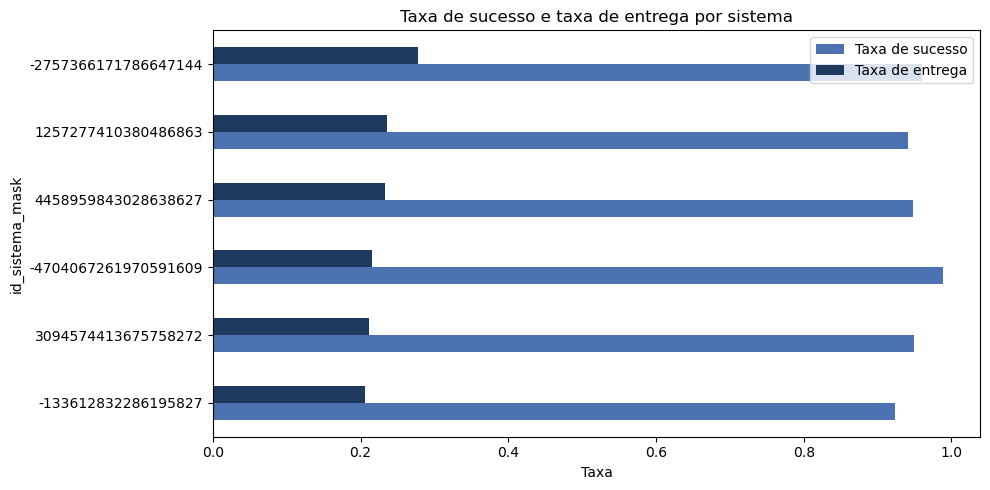

In [14]:
# Visualização: taxa de entrega e de sucesso por sistema

ax = resumo_sistema.sort_values('taxa_entrega').plot(
    x='id_sistema_mask',
    y=['taxa_sucesso', 'taxa_entrega'],
    kind='barh',
    figsize=(10, 5),
    title='Taxa de sucesso e taxa de entrega por sistema',
    color=['#4C72B0', '#1E3A5F']
)

ax.set_xlabel('Taxa')
ax.set_ylabel('id_sistema_mask')
ax.legend(['Taxa de sucesso', 'Taxa de entrega'])
plt.tight_layout()
plt.show()

- O sistema `-2757366171786647144` tem a maior taxa de entrega (27%).
- Já o sistema `-4704067261970591609` tem a maior taxa de alcance (98%).

###  Parte 1.2 - Janela de atualidade (decaimento)

Vamos separar os dias entre a atualização do número e a entrega da msg em faixas entre 0 e +730 dias. A ideia é ver se a data entre a última atualização impacta no sucesso dos disparos.

In [15]:
# Parte 1.2 - Janela de atualidade (decaimento)

base_dias = df[df['dias_desde_atualizacao'].notna()].copy()

bins = [-1, 30, 90, 180, 365, 730, 9999]
labels = ['0-30d', '31-90d', '91-180d', '181-365d', '366-730d', '+730d']

base_dias['faixa_atualizacao_dias'] = pd.cut(
    base_dias['dias_desde_atualizacao'],
    bins=bins,
    labels=labels
)

resumo_faixa = (
    base_dias.groupby('faixa_atualizacao_dias', observed=True)
              .agg(
                  tentativas=('id_disparo', 'count'),
                  taxa_entrega=('flag_entrega', 'mean'),
                  taxa_lida=('flag_lida','mean'),
                  taxa_sucesso=('flag_sucesso', 'mean'),
                  taxa_falha=('flag_falha', 'mean')
              )
              .round(4)
              .reset_index()
)

resumo_faixa

,faixa_atualizacao_dias,tentativas,taxa_entrega,taxa_lida,taxa_sucesso,taxa_falha
0,0-30d,7714,0.2188,0.7565,0.9754,0.0097
1,31-90d,33096,0.2208,0.7495,0.9702,0.0156
2,91-180d,307061,0.2093,0.7722,0.9815,0.0090
3,181-365d,111869,0.2295,0.7129,0.9424,0.0344
4,366-730d,98040,0.2281,0.7060,0.9341,0.0431
5,+730d,79896,0.2322,0.6964,0.9286,0.0546


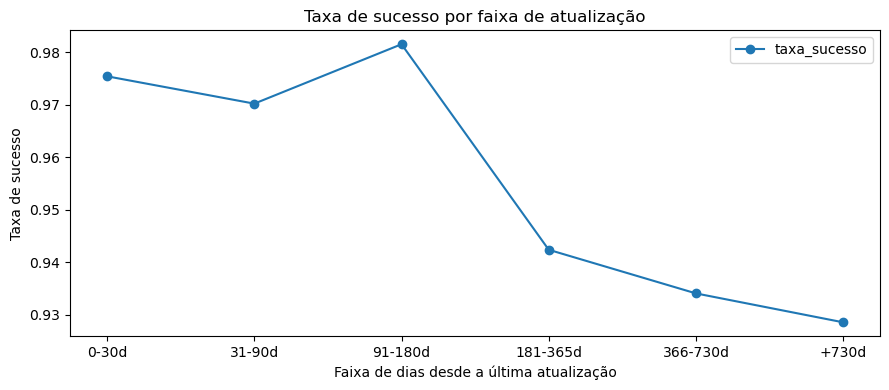

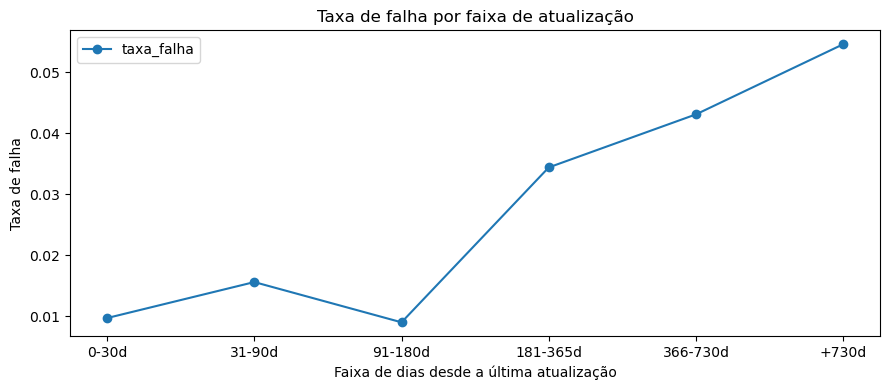

In [16]:
# Visualização da evolução de taxas por data de atualização

figsize = (9, 4)

ax = resumo_faixa.plot(
    x='faixa_atualizacao_dias',
    y='taxa_sucesso',
    marker='o',
    figsize=figsize,
    title='Taxa de sucesso por faixa de atualização'
)
ax.set_xlabel('Faixa de dias desde a última atualização')
ax.set_ylabel('Taxa de sucesso')
plt.tight_layout()
plt.show()

ax = resumo_faixa.plot(
    x='faixa_atualizacao_dias',
    y='taxa_falha',
    marker='o',
    figsize=figsize,
    title='Taxa de falha por faixa de atualização'
)
ax.set_xlabel('Faixa de dias desde a última atualização')
ax.set_ylabel('Taxa de falha')
plt.tight_layout()
plt.show()


- Quanto maior a quantidade de dias desde a última atualização, menor é a taxa de alcance, o que prejudica o sucesso do disparo.
- Na amostra enviada, o "prazo de validade" para um telefone ser considerado quente fica em torno de até 180 dias.

### Conclusões da Parte 1

1. Existem diferenças claras entre os sistemas quando medimos taxa de entrega e taxa de alcance.

    - O sistema `2757366171786647144` apresenta a maior taxa de entrega na amostra analisada. Já o sistema `-4704067261970591609` possui a maior taxa de alcance.
    - O sistema `-133612832286195827` apresenta as piores taxas de entrega e de alcance. Esse sistema também aparece com telefones mais antigos, em média.
    - Vale ressaltar que o sistema `-2757366171786647144` tem bom desempenho com volume muito menor de tentativas, enquanto o sistema `-4704067261970591609` precisou de maior número de tentativas.

2. Atualidade importa: quanto menos recente a atualização do telefone, menor tende a ser a chance de sucesso, indicando decaimento de qualidade ao longo do tempo.
    - Existe um prazo de validade prático para telefone "quente", com melhor desempenho nas faixas mais recentes de atualização, sendo esse prazo em torno de até 180 dias.

3. Parte da diferença observada entre as fontes pode estar ligada a viés de seleção, porque algumas bases aparecem muito mais no histórico do que outras.
    - Volume não pode ser confundido com qualidade: a leitura correta combina a taxa de entrega e qtde de tentativas.

4. Por fim, o "calor" do telefone depende ao mesmo tempo de duas dimensões: confiabilidade histórica da origem e tmepo desde a última atualização. Isso prepara diretamente a regra de score da Parte 2.


## Parte 2 - Inteligência de Priorização 

Implementar um ranking e algoritmo com base nas conclusões da Parte 1:

- sistemas de origem tem confiabilidades diferentes;
- atualidade do cadastro impacta o sucesso (decaimento);
- volume deve ser tratado para evitar supervalorizar bases pequenas.


### Parte 2.1 - Ranking de sistema

Construir um score de confiabilidade por sistema que leve em conta:

1. `score_origem`: taxa histórica de sucesso do sistema, ponderada por volume (com suavização bayesiana);
2. `score_atualidade`: atualidade dos registros (sem penalização até 180 dias e decaimento por meia-vida anual após esse ponto).

`Score sistema = 100 * score_origem * score_atualidade`

A métrica principal é a **taxa de sucesso de entrega** por sistema. Para evitar conclusões frágeis em sistemas com pouco volume, aplicamos um ajuste bayesiano simples:

$$
\text{taxa\_ajustada} = \frac{\text{sucessos} + \alpha \cdot \bar{p}}{\text{tentativas} + \alpha}
$$

onde p̄ é a taxa global e α controla o peso do prior.

In [17]:
# Definir parâmetro da suaviazação bayesiana com base nas tentativas

df.groupby('id_sistema_mask')['id_disparo'].count().describe()

count         6.000000
mean     124780.500000
std       96587.308137
min        6829.000000
25%       42486.250000
50%      140497.500000
75%      190516.250000
max      243854.000000
Name: id_disparo, dtype: float64

In [18]:
# Score origem

df['sucesso_origem'] = df['flag_sucesso'].astype('int64')

ranking_sistemas = (
    df.groupby('id_sistema_mask', as_index=False)
    .agg(
        tentativas=('id_disparo', 'count'),
        sucessos=('sucesso_origem', 'sum'),
        taxa_sucesso=('sucesso_origem', 'mean'),
        mediana_dias=('dias_desde_atualizacao', 'median'),
        media_dias=('dias_desde_atualizacao', 'mean')
    )
)

# Suavização bayesiana para reduzir volatilidade de sistemas com baixo volume

taxa_global = df['sucesso_origem'].mean()
prior = 6000 # força de suavização

ranking_sistemas['score_origem'] = (
    ranking_sistemas['sucessos'] + taxa_global * prior
) / (
    ranking_sistemas['tentativas'] + prior
)

ranking_sistemas.sort_values(by='taxa_sucesso',ascending=False)

,id_sistema_mask,tentativas,sucessos,taxa_sucesso,mediana_dias,media_dias,score_origem
2,-4704067261970591609,197224,195092,0.989190,147.0,130.210309,0.988156
1,-2757366171786647144,6829,6560,0.960609,303.0,297.255674,0.957590
4,3094574413675758272,243854,231506,0.949363,153.0,292.641330,0.949478
5,4458959843028638627,19781,18760,0.948385,298.0,306.569739,0.949727
3,1257277410380486863,170393,160364,0.941142,478.0,749.094371,0.941585
0,-133612832286195827,110602,102076,0.922913,839.0,1086.352517,0.924520


In [19]:
# Fator de recência: sem penalizar até 180 dias; depois decai por meia-vida anual

ranking_sistemas['score_atualidade'] = np.where(
    ranking_sistemas['mediana_dias'] <= 180,
    1.0,
    np.exp(-np.log(2) * (ranking_sistemas['mediana_dias'] - 180) / 365)
)

In [20]:

# Score final da origem na escala [0, 100]
ranking_sistemas['score_sistema'] = (
    100
    * ranking_sistemas['score_origem']       # suavização bayesiana
    * ranking_sistemas['score_atualidade']   # fator de recência
)

# Ordenação final do ranking
ranking_sistemas = ranking_sistemas.sort_values(
    ['score_sistema', 'tentativas'],
    ascending=[False, False]
).reset_index(drop=True)

ranking_sistemas['rank_origem'] = ranking_sistemas.index + 1

ranking_sistemas['classe_confiabilidade'] = pd.qcut(
    ranking_sistemas['score_sistema'],
    q=3,
    labels=['Baixa', 'Media', 'Alta'],
    duplicates='drop'
)

ranking_sistemas[
    [
        'rank_origem',
        'id_sistema_mask',
        'tentativas',
        'taxa_sucesso',
        'mediana_dias',
        'score_origem',
        'score_atualidade',
        'score_sistema',
        'classe_confiabilidade'
    ]
]

,rank_origem,id_sistema_mask,tentativas,taxa_sucesso,mediana_dias,score_origem,score_atualidade,score_sistema,classe_confiabilidade
0,1,-4704067261970591609,197224,0.989190,147.0,0.988156,1.000000,98.815552,Alta
1,2,3094574413675758272,243854,0.949363,153.0,0.949478,1.000000,94.947816,Alta
2,3,4458959843028638627,19781,0.948385,298.0,0.949727,0.799246,75.906609,Media
3,4,-2757366171786647144,6829,0.960609,303.0,0.957590,0.791693,75.811735,Media
4,5,1257277410380486863,170393,0.941142,478.0,0.941585,0.567842,53.467130,Baixa
5,6,-133612832286195827,110602,0.922913,839.0,0.924520,0.286086,26.449227,Baixa


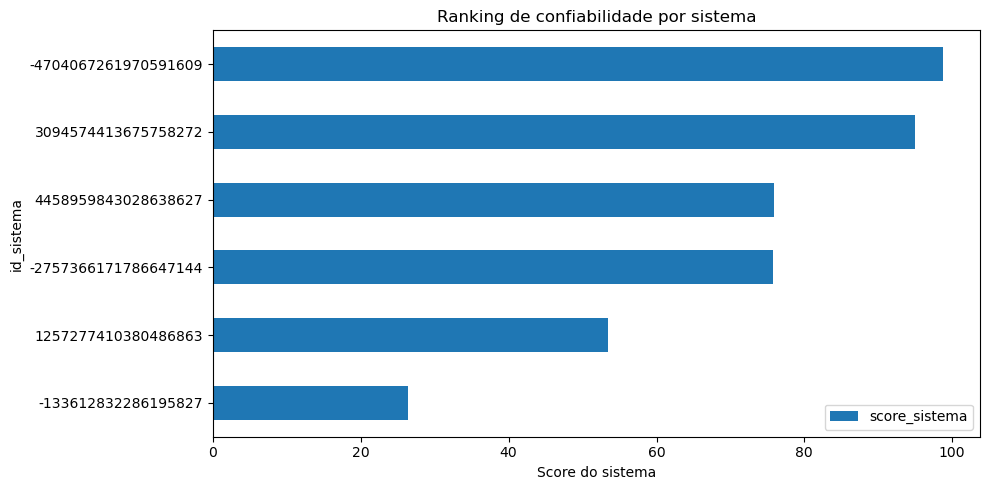

In [21]:

ax = ranking_sistemas.sort_values('score_sistema').plot(
    x='id_sistema_mask',
    y='score_sistema',
    kind='barh',
    figsize=(10, 5),
    title='Ranking de confiabilidade por sistema'
)
ax.set_xlabel('Score do sistema')
ax.set_ylabel('id_sistema')
plt.tight_layout()
plt.show()



#### Por que o sistema X é melhor que o Y?

Porque ele combina melhor os componentes de robustez do score de origem:

1. **taxa ajustada de sucesso** maior;
2. **volume** suficiente para sustentar essa taxa (via suavização bayesiana);
3. atualizações **mais recentes** de telefone.

Exemplo:
- o sistema `-4704067261970591609` tende a ficar no topo porque mantém **taxa ajustada muito alta** com alto volume de observações;
- sistemas com menor taxa ajustada e/ou menor robustez estatística tendem a ficar abaixo.

Ou seja, o ranking não premia só “quem acerta mais”, mas “quem acerta mais de forma estatisticamente robusta”.


### Parte 2.2 - Algoritmo de escolha

Além do fator de confiabilidade do sistema de origem e atualidade dos registros telefônicos, no algoritmo final podemos incluir o DDD e a qualidade do telefone.

In [22]:
# Base de score por aparição de telefone
base_score = (
    df.dropna(subset=['id_sistema_mask'])
      .merge(
          ranking_sistemas[['id_sistema_mask', 'score_origem', 'score_sistema']],
          on='id_sistema_mask',
          how='left'
      )
      .copy()
)

# Fator de qualidade do telefone
base_score['fator_qualidade'] = np.select(
    [
        base_score['telefone_qualidade'].eq('VALIDO'),
        base_score['telefone_qualidade'].eq('SUSPEITO'),
        base_score['telefone_qualidade'].eq('INVALIDO')
    ],
    [1.00, 0.85, 0.30],
    default=0.75
)

# Sinal por DDD com suavização por volume
taxa_ddd = (
    base_score.dropna(subset=['telefone_ddd'])
              .groupby('telefone_ddd', as_index=False)
              .agg(
                  tentativas_ddd=('id_disparo', 'count'),
                  sucessos_ddd=('flag_sucesso', 'sum')
              )
)

prior_ddd = 200
taxa_ddd['score_ddd'] = (
    taxa_ddd['sucessos_ddd'] + prior_ddd * taxa_global
) / (
    taxa_ddd['tentativas_ddd'] + prior_ddd
)

base_score = base_score.merge(taxa_ddd[['telefone_ddd', 'score_ddd']], on='telefone_ddd', how='left')
base_score['score_ddd'] = base_score['score_ddd'].fillna(taxa_global)

In [23]:
# Probabilidade da aparição (escala 0-1)
base_score['p_aparicao'] = (
    (base_score['score_sistema'] / 100.0)
    * base_score['fator_qualidade']
    * base_score['score_ddd']
).clip(0, 0.999)

# Consolidação por CPF + telefone
candidatos = (
    base_score.groupby(['cpf', 'contato_telefone'], as_index=False)
              .agg(
                  n_sistemas=('id_sistema_mask', 'nunique'),
                  melhor_sistema=('id_sistema_mask', 'first'),
                  melhor_ddd=('telefone_ddd', 'first'),
                  melhor_score_sistema=('score_sistema', 'max'),
                  melhor_p_aparicao=('p_aparicao', 'max')
              )
)

# Score final
candidatos['score_final_telefone'] = (
    100 * candidatos['melhor_p_aparicao']
).clip(0, 100)

# Top-2 telefones por CPF
top2_por_cpf = (
    candidatos.sort_values(['cpf', 'score_final_telefone'], ascending=[True, False])
              .groupby('cpf', as_index=False)
              .head(2)
)

display(
    top2_por_cpf[
        [
            'cpf', 'contato_telefone', 'score_final_telefone',
            'melhor_score_sistema', 'n_sistemas',
            'melhor_sistema', 'melhor_ddd'
        ]
    ].head(20)
)
print('CPFs com pelo menos 2 telefones sugeridos:', top2_por_cpf['cpf'].nunique())

,cpf,contato_telefone,score_final_telefone,melhor_score_sistema,n_sistemas,melhor_sistema,melhor_ddd
0,-9.223348e+18,-78249539818182761,94.350663,98.815552,3,-4704067261970591609,-1.181434e+18
1,-9.223336e+18,-846384703661013523,94.350663,98.815552,2,-4704067261970591609,-1.181434e+18
2,-9.223229e+18,1054853349670880571,94.350663,98.815552,2,-4704067261970591609,-1.181434e+18
3,-9.222883e+18,923103163056149731,90.657687,94.947816,1,3094574413675758272,-1.181434e+18
4,-9.222836e+18,-7905013845993143661,94.350663,98.815552,2,-4704067261970591609,-1.181434e+18
5,-9.222591e+18,-8167963762075239610,94.350663,98.815552,1,-4704067261970591609,-1.181434e+18
6,-9.222453e+18,-2454509415503044633,94.350663,98.815552,3,-4704067261970591609,-1.181434e+18
7,-9.222404e+18,-2648450204219839323,90.657687,94.947816,1,3094574413675758272,-1.181434e+18
8,-9.222332e+18,-2326684078955202336,94.350663,98.815552,2,-4704067261970591609,-1.181434e+18
9,-9.222329e+18,2627875740532485028,90.657687,94.947816,1,3094574413675758272,-1.181434e+18


CPFs com pelo menos 2 telefones sugeridos: 240689


## Parte 3 - Proposta de experimento A/B

### Hipótese
- **H0 (nula):** a taxa de sucesso da nova estratégia (ranking + recência + DDD) é igual à estratégia atual.
- **H1 (alternativa):** a nova estratégia aumenta a taxa de sucesso.

### Métricas
- **Primária:** taxa de sucesso de entrega (`delivered` ou `read`).
- **Secundárias:** custo por entrega bem-sucedida, taxa de leitura, tempo até primeira entrega.

### Unidade e randomização
- Randomização por CPF (ou id_target), para evitar contaminação entre telefones do mesmo cidadão.

### Critério operacional
- Grupo A: estratégia atual.
- Grupo B: seleção top-2 pelo `score_final`.

In [24]:
# Cálculo aproximado de amostra para teste de proporções (one-sided)
# Exemplo: detectar aumento absoluto de 2 p.p. com 80% de poder e 5% de significância

p_base = taxa_global
mde = 0.02
p_teste = p_base + mde

# aproximação normal: n por grupo
z_alpha = 1.645  # one-sided 5%
z_beta = 0.842   # 80% power

p_pool = (p_base + p_teste) / 2
num = (z_alpha * np.sqrt(2 * p_pool * (1 - p_pool)) + z_beta * np.sqrt(p_base * (1 - p_base) + p_teste * (1 - p_teste))) ** 2
den = (p_teste - p_base) ** 2
n_por_grupo = int(np.ceil(num / den))

print(f'Taxa base estimada: {p_base:.4f}')
print(f'Efeito mínimo detectável (absoluto): {mde:.4f}')
print(f'Amostra estimada por grupo: {n_por_grupo:,}')

# Estimativa de duração do experimento (ajuste o throughput diário conforme operação real)
throughput_diario = 30000  
dias_totais = int(np.ceil((2 * n_por_grupo) / throughput_diario))
print(f'Duração estimada (com {throughput_diario:,} envios/dia): ~{dias_totais} dias')

Taxa base estimada: 0.9542
Efeito mínimo detectável (absoluto): 0.0200
Amostra estimada por grupo: 1,068
Duração estimada (com 30,000 envios/dia): ~1 dias


## Conclusão Executiva

O experimento indica ganho operacional com a priorização de contatos por probabilidade de entrega, combinando **score de sistema**, **qualidade da fonte** e **coerência de DDD**. Na prática, isso reduz tentativas improdutivas e aumenta a chance de sucesso por CPF sem crescimento proporcional de custo.

**Regra acionável executiva (para operação):**
- Selecionar até 2 telefones por CPF, ordenados por `score_final_telefone`.
- **Telefone 1:** disparo imediato quando `score_final_telefone >= 90`.
- **Telefone 2 (fallback):** disparar apenas se não houver `delivered/read` do telefone 1 em 24h, e se `score_final_telefone >= 85`.
- Se nenhum telefone atingir 85, enviar CPF para fluxo de atualização/enriquecimento cadastral antes de novas tentativas.

**Critério de decisão para rollout:** manter a nova regra se o teste A/B confirmar ganho estatisticamente significativo na taxa de entrega (meta mínima de +2 p.p.) e redução de custo por entrega bem-sucedida.